In [ ]:
import sys

# Step 1: Install gpjax (brings in numpyro, jax, etc.)
!{sys.executable} -m pip install -q gpjax

# Step 2: Patch numpyro's provenance.py for JAX 0.10.0 compatibility
# (xla_pmap_p was removed in JAX 0.10.0 but numpyro 0.20.1 still references it)
!sed -i 's/from jax.extend.core.primitives import call_p, closed_call_p, jit_p, xla_pmap_p/from jax.extend.core.primitives import call_p, closed_call_p, jit_p/' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

!sed -i 's/track_deps_rules\[xla_pmap_p\] = track_deps_call_rule//' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

print("Patch applied. Now restart your session, then import gpjax.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.8 MB/s eta 0:00:00
Patch applied. Now restart your session, then import gpjax.


In [ ]:
import gpjax
print(gpjax.__version__)  # Should work cleanly

0.13.6


In [ ]:
#import gpjax
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import arviz as az

# Replace this:
# gpjax.utils.enable_x64()

# With this:
import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=np.arctan((x-A+(0.5*m))/(D))-np.arctan((x-A-(0.5*m))/(D))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    g=2*G*rho*f #in miligal
    return g

#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
def g_n_anomaly(N,x,A,m,D,d,rho):
    u=0
    for i in range(N):
        v=g_anomaly(x,A[i],m[i],D[i],d[i],rho[i])
        u=u+v

    return u

In [ ]:
#SETTING FORWARD MODEL PARAMETERS

#Defining bottom depths of two layers by bd1 and bd2. Each element of bd1 representing bottom depth value of one prism. same for bd2 in meter
bd1=np.array([500,510,520,530,540,545,550,545,540,530,520,490,470,460,450,440,420,410,400,390,385,380,385,390,400,410,420,430,460,470])
bd2=np.array([800,790,780,770,760,755,750,755,760,770,780,810,830,840,850,860,880,890,900,910,915,920,915,910,900,890,880,870,850,830])
n= 30 #We are considering 30 prisms here for real world case
#surface value in meter

# Defining centre value of horizontal co-ordinate of each prism
co=np.linspace(-4350,4350,n)
# Defining width of each prism
wid=np.zeros(n)
for j in range(n):
    wid[j]= 300 # in meter

#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1[0]
zs1[n]=bd1[n-1]
for i in range(1,n):
    zs1[i]=bd1[i]
#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2[0]-5
zs2[n]=bd2[n-1]+5
for i in range(1,n):
    zs2[i]=(bd2[i-1]+bd2[i])*0.5
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]
#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]
#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]



n=40
# Defining centre value of horizontal co-ordinate of each prism
td=np.zeros(n)
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)
co0=np.linspace(-4375,4375,n)
# Defining width of each prism
wid0=np.zeros(n)
for j in range(n):
    wid0[j]= 9000/n # in meter

#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co0[0]-(wid0[0]*0.5)
xs[n]=co0[n-1]+(wid0[n-1]*0.5)
for i in range(1,n):
    xs[i]=co0[i-1]+(0.5*wid0[i-1])

from scipy import interpolate
y_f1=interpolate.interp1d(co, bd1, fill_value="extrapolate", kind='linear')
bd1_0=y_f1(co0)

y_f2=interpolate.interp1d(co, bd2, fill_value="extrapolate", kind='linear')
bd2_0=y_f2(co0)

#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]

#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1_0[0]
zs1[n]=bd1_0[n-1]
for i in range(1,n):
    zs1[i]=bd1_0[i]

#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2_0[0]
zs2[n]=bd2_0[n-1]
for i in range(1,n):
    zs2[i]=bd2_0[i]

#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]


#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]

#Creating points for 1st layer
R2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_1[i]=[xs[i+1],zs2[i]]

#Defining constant density contrasts in kg per m^3
den1_0=np.zeros(n)
for i in range(n):
    den1_0[i]=-150
import numpy as np
#USING LINEAR VARIATION OF DENSITY
den1_L=np.zeros(n)
for i in range(n):
    den1_L[i]=-100-i*3
den2_L=np.zeros(n)
for i in range(n):
    den2_L[i]=-220-i*2

density_layered = np.full((n, int(np.max(bd1_0) / 30) + 1),fill_value=np.nan)
for i in range(n):
    z_inc = np.arange(0,bd1_0[i]+1,30)
    for j in range(len(z_inc)-1):
        density_layered[i,j] = -(200 + i * 2) + j * 10

BD = []
for i in range(n):
    z_inc = np.arange(0,bd1_0[i]+1,30)
    BD.append(max(z_inc))

In [ ]:
#Defining a fuction to calculate anomaly for the layer having both vertical and lateral variation of density by dividing each layer into interval of a prism of height equals to 40 meter
def measure_func(x):
    y1_v=np.zeros(len(x))
    for i in range(n):
        g1=np.zeros(len(x))
        g2=np.zeros(len(x))
        z_v_1=np.arange(0,bd1_0[i]+1,30)#dividing the depth into 30 meter intervals
        #calculation of the anomaly of the 1st prism in that depth column
        for k in range(1):
            #rho1=-(90+i*5)-k*5 #Defining vertically as well as laterally varying density
            val1=g_anomaly(x,co0[i],wid0[i],z_v_1[k+1]+0.001,z_v_1[k]+0.001,density_layered[i,k])
            g1=g1+val1
        #calculation of the anomaly of the rest of the prisms in that depth column
        for k in range(1,len(z_v_1)-1):
            #rho2=-(90+i*5)-k*5 #Defining vertically as well as laterally varying density
            val2=g_anomaly(x,co0[i],wid0[i],z_v_1[k+1]+0.001,z_v_1[k]+0.001,density_layered[i,k])
            g2=g2+val2
        #summing up all the values
        y1_v=y1_v+g1+g2
    return y1_v


In [ ]:
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS) #measurement stations along the profile of -5000 meter to 5000 meters
X_test = np.linspace(-5000, 5000, 100) #points taken for testing at finer intervals
ground_truth=measure_func(X) #Gravity anomaly in miligal at finer intervals with no added noise

In [ ]:
import tensorflow as tf
# Set seeds for reproducibility
#best for SEED NUMBER 72
#experiment 45
SEED = 45
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise =0.8*np.random.normal(0, 0.15, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.04, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Adding noise to the gravity anomaly data
y = measure_func(X)+(gaussian_noise+random_walk_noise+salt_and_pepper_noise)*1 #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X)#interpolating between noisy observations at finer fintervals


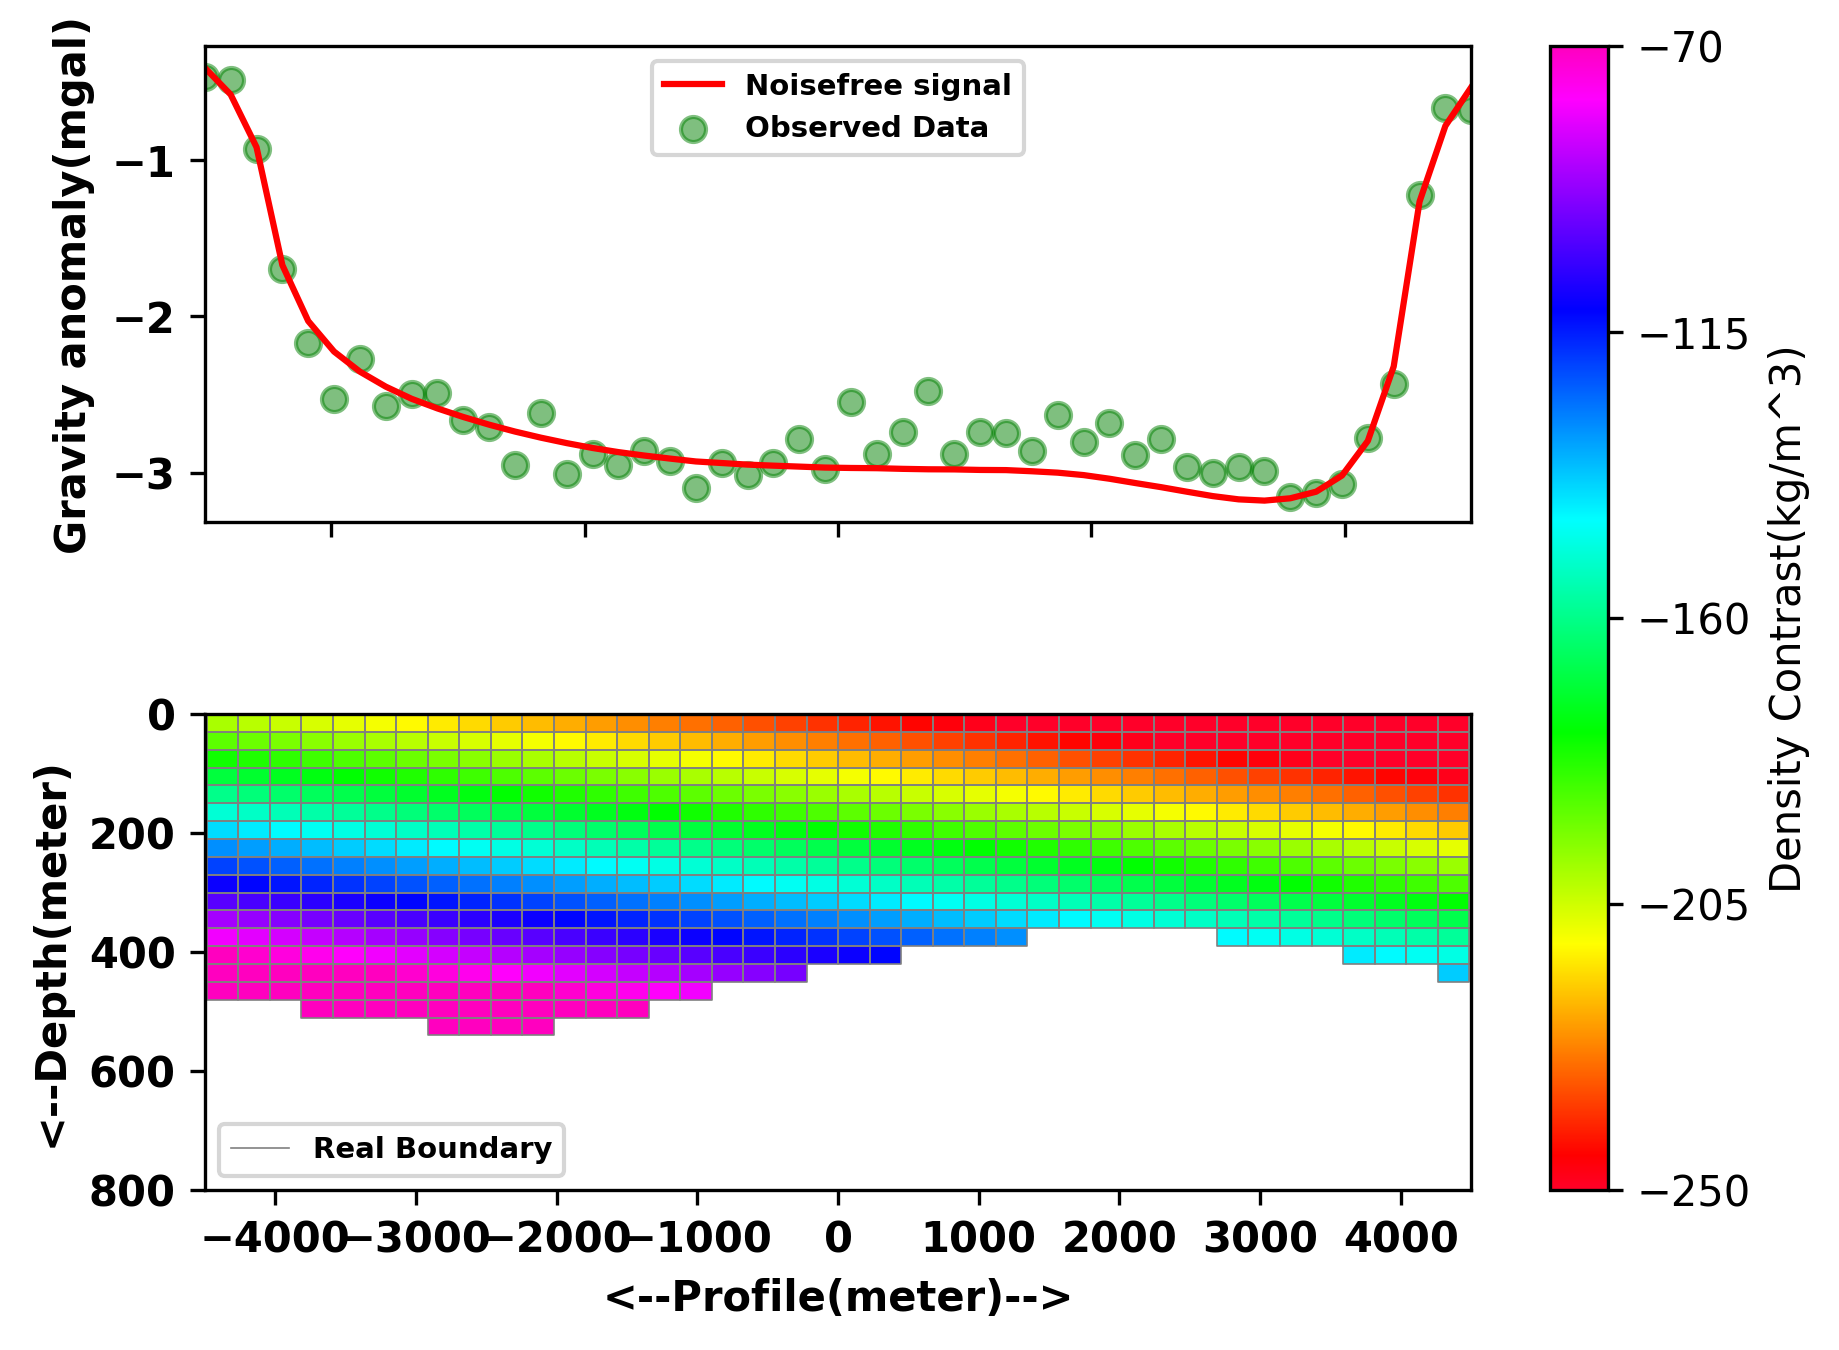

In [ ]:
from os import R_OK
import matplotlib.pyplot as plt
import matplotlib as mpl
#import matplotlib.pyplot as plt
fig, axs = plt.subplots(2)
fig.dpi=300
fig.tight_layout(pad=2.5)
zs0_V=np.zeros(n+1)

co=co0
wid=wid0
bd1=bd1_0
bd2=bd2_0
#Creating x co-ordinates
xs_V=np.zeros(n+1)
xs_V[0]=co[0]-(wid[0]*0.5)
xs_V[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_V[i]=co[i-1]+(0.5*wid[i-1])
#Creating z Co-ordinates
zs1_V=np.zeros(n+1)
zs1_V[0]=BD[0]
zs1_V[n]=BD[n-1]
for i in range(1,n):
    zs1_V[i]=(BD[i-1]+BD[i])*0.5

#Defining points
R0_V=np.zeros(((n+1),2))
R1_V=np.zeros(((n+1),2))
R_V=np.zeros((n,2))


cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=-70 #maximum density in kg per m^3 in colorscale
minimum_V=-250 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
###################
for i in range(n):
    #First dividing each depth into 30 meter intervals
    z_v_1=np.arange(0,zs1_V[i]+1,30)
    den1_V=np.zeros(len(z_v_1))
    color_index_V = np.linspace(minimum_V,maximum_V,len(z_v_1)-1)
    #1st prism in that depth column
    for j in range(0,1):
        den1_V[j]=density_layered[i,j] #Defining vertically as well as laterally varying density
        #choosing the color according to the density value of the prism
        index_value_V = (den1_V[j]-minimum_V)/diff_V
        color_V = cmap_V(index_value_V)
        #Defining 4 corner co-ordinates of that prism in the depth column
        R0_V[j]=[xs_V[i],0]
        R1_V[j]=[xs_V[i],z_v_1[j+1]]
        R0_V[j+1]=[xs_V[i+1],0]
        R1_V[j+1]=[xs_V[i+1],z_v_1[j+1]]
        #creating the prism using 4 corner co-ordinates
        coord_V = [R0_V[j], R0_V[j+1], R1_V[j+1], R1_V[j]]
        coord_V.append(coord_V[0]) #repeat the first point to create a 'closed loop'
        x1_V, y1_V = zip(*coord_V) #create lists of x and y values
        axs[1].plot(x1_V,y1_V,'grey',linewidth=0.4)#plotting prism
        axs[1].fill(x1_V, y1_V, facecolor=color_V)#color filling that prism acc to its density value
        axs[1].set_xlim(-4650,4350)
        axs[1].set_ylim(1000,0)
####################
for i in range(n):
    z_v_1=np.arange(0,zs1_V[i]+1,30)
    den1_V=np.zeros(len(z_v_1))
    color_index_V = np.linspace(minimum_V,maximum_V,len(z_v_1)-1)
    #rest of the prisms in that depth column
    for j in range(1,len(z_v_1)-1):
        den1_V[j]=density_layered[i,j] #Defining vertically as well as laterally varying density
        #choosing the color according to the density value of the prism
        index_value_V = (den1_V[j]-minimum_V)/diff_V
        #Defining 4 corner co-ordinates of that prism in the depth column
        color_V = cmap_V(index_value_V)
        R1_V[j]=[xs_V[i],z_v_1[j+1]]
        R_V[j]= [xs_V[i],z_v_1[j]]
        R1_V[j+1]=[xs_V[i+1],z_v_1[j+1]]
        R_V[j+1]=[xs_V[i+1],z_v_1[j]]
        #creating the prism using 4 corner co-ordinates
        coord_V = [R_V[j], R_V[j+1], R1_V[j+1], R1_V[j]]
        coord_V.append(coord_V[0]) #repeat the first point to create a 'closed loop'
        x1_V, y1_V = zip(*coord_V) #create lists of x and y values
        axs[1].plot(x1_V,y1_V,'grey',linewidth=0.4)#plotting prisms
        axs[1].fill(x1_V, y1_V, facecolor=color_V)#color filling that prism acc to its density value

        axs[1].set_xlim(-4650,4350)
        axs[1].set_ylim(800,0)
#axs[1].plot(co,np.array(BD))
# Normalizer
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)

# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')
axs[0].plot(X, ground_truth,c='red', label="Truth Signal")#gravity anomaly at finer intervals without noise
axs[0].scatter(X,y,alpha=0.5, c='green', marker='o', label="Noisy observations")#observed anomaly
axs[0].legend()
axs[0].set_ylabel("Gravity Anomaly (mGal)",weight='bold')
#axs[1].plot(co,bd1)
axs[1].set_ylabel("<--Depth(meter)",weight='bold')
axs[1].set_xlabel("<--Profile(meter)-->",weight='bold')
axs[1].set_xlim(-4500,4500)
axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(["Noisefree signal",'Observed Data'],prop=legend_properties)
axs[1].legend(['Real Boundary'],prop=legend_properties)
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= False,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
axs[0].set_ylabel("Gravity anomaly(mgal)",fontsize=10,weight='bold')
import warnings
warnings.filterwarnings('ignore')

## INVERSION




In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


#print(X.shape, y.shape)  # confirm: (50, 1) (50,)



In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


In [ ]:
# CUSTOM MATERN KERNEL FOR v=3/2
def custom_Matern_kernel(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

    # Example of a custom kernel prior for the above kernels
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters."""
    import numpyro.distributions as dist
    k_scale = numpyro.sample("k_scale",dist.HalfNormal(1))
    k_length = numpyro.sample("k_length",dist.LogNormal(0,1))
    return {"k_length": k_length, "k_scale": k_scale}


In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_vertical_2(x_train_1d, mean_params_i)
        mean_test  = Bayes_vertical_2(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

In [ ]:
#05/04/2026
import random
random.seed(45)
LAYER_THICKNESS  = 30.0    # metres

# Prior bounds drawn randomly — wide enough to be uninformative
# These are still concrete floats so np.arange can use them
depth_lo_bounds = [random.uniform(float(BD[i])-50,float(BD[i])-20) for i in range(n)]
depth_hi_bounds = [random.uniform(float(BD[i])+20,float(BD[i])+50) for i in range(n)]
#den_lo_bounds = [random.uniform(float(min(density_layered[i]))-20,float(min(density_layered[i]))-10) for i in range(n)]
#den_hi_bounds = [random.uniform(float(max(density_layered[i]))+10,float(max(density_layered[i]))+20) for i in range(n)]

# Fixed grid built only from GLOBAL_MAX_DEPTH — no bd1_0 involved
Z_GRID_PER_PRISM         = [np.arange(0, depth_hi_bounds[i] , LAYER_THICKNESS) for i in range(n)]
N_LAYERS_PER_PRISM = [len(Z_GRID_PER_PRISM[i]) - 1 for i in range(n)]


def Bayes_vertical_prior_2():
    params = {}

    for i in range(n):
        # ── Bottom depth prior ───────────────────────────────────
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}",
            dist.Uniform(depth_lo_bounds[i], depth_hi_bounds[i])
        )
        params[f"density_min_{i+1}"]=numpyro.sample(
            f"density_min_{i+1}",
            dist.Uniform(float(min(density_layered[i]))-20, float(min(density_layered[i]))-10)
        )
        params[f"density_max_{i+1}"]=numpyro.sample(
            f"density_max_{i+1}",
            dist.Uniform(float(max(density_layered[i]))+10, float(max(density_layered[i]))+20)
        )

    return params



def Bayes_vertical_2(x, params):
    y1_v = jnp.zeros(len(x))

    for i in range(n):
        B_D1     = params[f"B_D1_{i+1}"]    # JAX tracer — the actual bottom depth
        den_min  = params[f"density_min_{i+1}"]
        den_max  = params[f"density_max_{i+1}"]
        z_grid   = Z_GRID_PER_PRISM[i]       # concrete numpy array
        n_layers = N_LAYERS_PER_PRISM[i]     # concrete int
        rho = jnp.linspace(den_min,den_max,n_layers)
        g_prism = jnp.zeros(len(x))

        for k in range(n_layers):
            z_top = float(z_grid[k]) + 0.001

            # For all layers except the last: z_bot is the fixed grid value
            # For the last layer: z_bot is the sampled B_D1 itself
            # This way B_D1 directly controls the bottom of the prism
            if k < n_layers - 1:
                z_bot = float(z_grid[k + 1]) + 0.001
            else:
                z_bot = B_D1 + 0.001         # ← B_D1 used directly here


            val = g_ano(x, co0[i], wid0[i], z_bot, z_top, rho[k])

            g_prism = g_prism + val

        y1_v = y1_v + g_prism

    return y1_v

def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_vertical_prior_2()
    mean_vec    = Bayes_vertical_2(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)


# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model), num_warmup=4000, num_samples=1000, num_chains=1)
#mcmc1 = MCMC(NUTS(gp_model), num_warmup=20, num_samples=10, num_chains=1)
mcmc1.run(rng_key, X, y)
mcmc1.print_summary()
samples1 = mcmc1.get_samples()

sample: 100%|██████████| 5000/5000 [14:21<00:00,  5.80it/s, 31 steps of size 1.85e-01. acc. prob=0.88]



                      mean       std    median      5.0%     95.0%     n_eff     r_hat
          B_D1_1    482.45     26.15    481.77    444.97    525.20   1810.97      1.00
         B_D1_10    548.08     21.07    547.32    514.10    578.65   1880.54      1.00
         B_D1_11    526.90     20.28    526.45    491.70    555.76   1462.48      1.00
         B_D1_12    509.96     19.00    508.60    480.29    537.67   1318.97      1.00
         B_D1_13    496.81     19.92    496.32    464.06    525.15   2020.12      1.00
         B_D1_14    511.90     16.66    511.38    487.05    537.73   2069.36      1.00
         B_D1_15    487.11     21.37    486.39    452.84    517.61   1313.60      1.00
         B_D1_16    474.18     23.93    472.60    436.57    508.77   1319.36      1.00
         B_D1_17    446.98     13.28    446.25    425.54    466.27   1482.48      1.00
         B_D1_18    453.92     21.58    451.37    421.57    485.67   1189.96      1.00
         B_D1_19    437.97     24.40    43

In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_vertical_2(x_train_1d, mean_params_i)
        mean_test  = Bayes_vertical_2(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

In [ ]:
params7 = mcmc1.get_samples()

# Inverted bottom depths (one per prism)
inverted_depths = np.zeros(n)
density1_min = np.zeros(n)
density1_max = np.zeros(n)
for i in range(n):
    inverted_depths[i] = params7[f"B_D1_{i+1}"].mean()
    density1_min[i] = params7[f"density_min_{i+1}"].mean()
    density1_max[i] = params7[f"density_max_{i+1}"].mean()

# ── Step 1: Run gp_predict to get pred_mean and pred_std ────
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred, y_sampled, pred_mean, pred_std = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)

# Use sample statistics (same as your original Cell 27)
pred_mean = np.array(y_sampled.mean(0))
pred_std  = np.array(y_sampled.std(0))

params7 = mcmc1.get_samples()

inverted_depths = np.zeros(n)
inverted_depths_std = np.zeros(n)
for i in range(n):
    inverted_depths[i]     = params7[f"B_D1_{i+1}"].mean()
    inverted_depths_std[i] = params7[f"B_D1_{i+1}"].std()

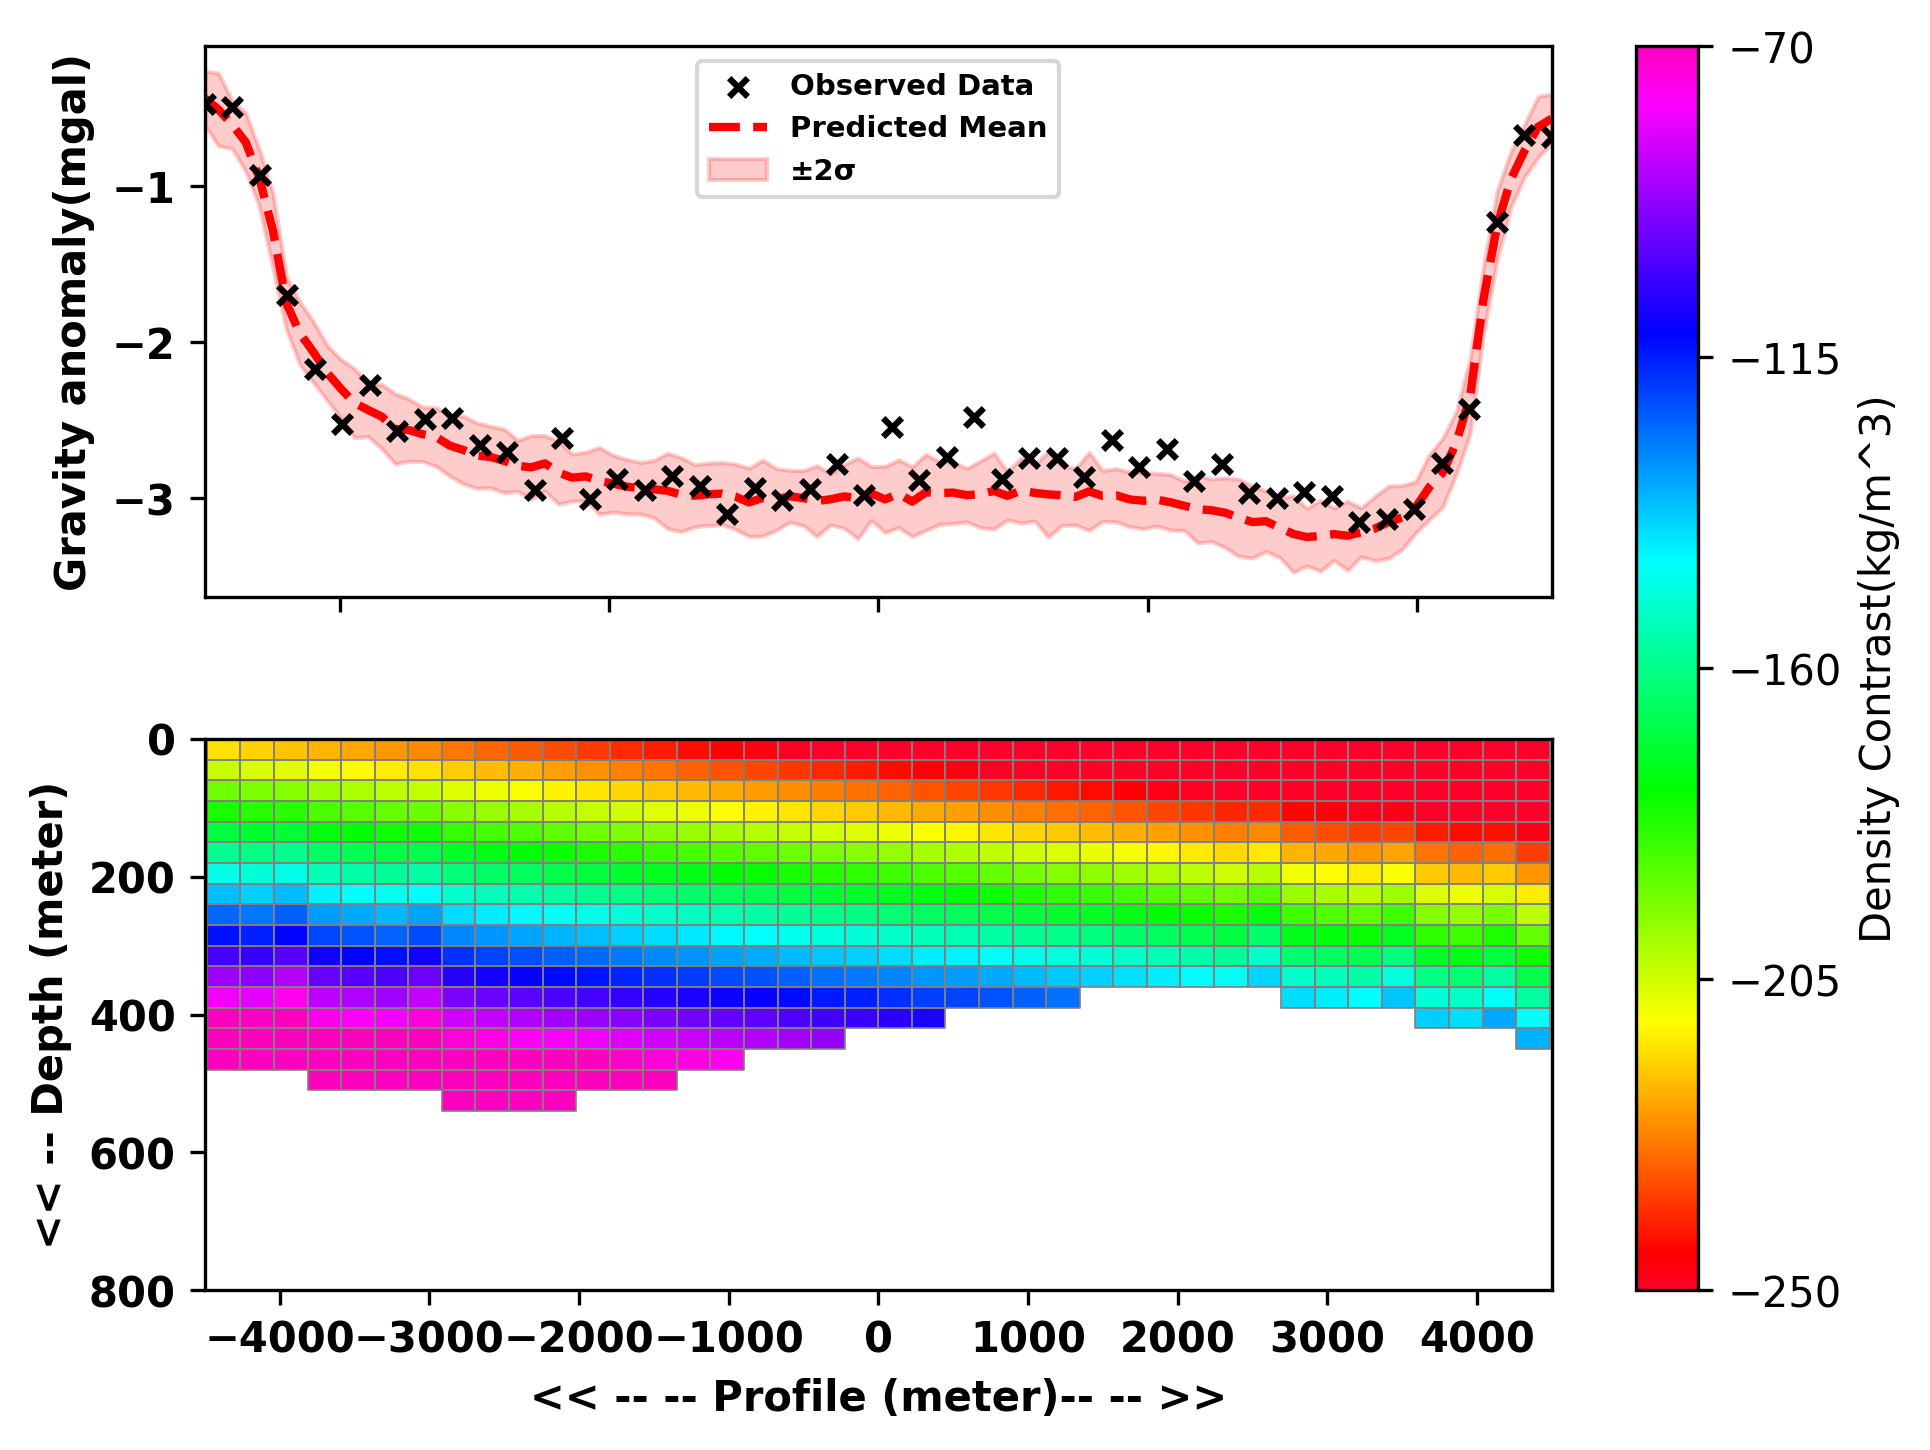

In [ ]:
#PLOT THE INVERTED RESULTS FOR THE CASE HAVING GOOD PRIOR KNOWLEDGE
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.3)
fig.dpi=300


cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=-70 #maximum density in kg per m^3 in colorscale
minimum_V=-250 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)

for i in range(n):
    z_v_1=np.arange(0,inverted_depths[i]+1,30)#dividing each depth into 40 meter intervals
    color_index_V = np.linspace(minimum_V,maximum_V,len(z_v_1)-1)
    den_min_1=density1_min[i]
    den_max_1=density1_max[i]
    den1_inv_V= np.linspace(den_min_1,den_max_1,len(z_v_1))
    #1st prism in that depth column
    for j in range(0,1):
        #choosing the color according to the inverted density value of the prism
        index_value_V = (den1_inv_V[j]-minimum_V)/diff_V
        color_V = cmap_V(index_value_V)
        #Defining 4 corner co-ordinates of that prism in the depth column
        point_bottom_left = [xs_V[i], 0]
        point_bottom_right = [xs_V[i+1], 0]
        point_top_right = [xs_V[i+1], z_v_1[j+1]]
        point_top_left = [xs_V[i], z_v_1[j+1]]
        coord_V = [point_bottom_left, point_bottom_right, point_top_right, point_top_left]
        coord_V.append(coord_V[0]) #repeat the first point to create a 'closed loop'
        x1_V, y1_V = zip(*coord_V) #create lists of x and y values
        axs[1].plot(x1_V,y1_V,'grey',linewidth=0.4)#plotting prism
        axs[1].fill(x1_V, y1_V, facecolor=color_V)#color filling that prism acc to its inverted density value
        axs[1].set_xlim(-4500,4500)
        axs[1].set_ylim(800,0)

for i in range(n):
    z_v_1=np.arange(0,zs1_V[i]+1,30)#dividing each depth into 40 meter intervals
    color_index_V = np.linspace(minimum_V,maximum_V,len(z_v_1)-1)
    den_min_1=density1_min[i]
    den_max_1=density1_max[i]
    den1_inv_V= np.linspace(den_min_1,den_max_1,len(z_v_1))

    #rest of the prisms in that depth column
    for j in range(1,len(z_v_1)-1):
        #choosing the color according to the inverted density value of the prism
        index_value_V = (den1_inv_V[j]-minimum_V)/diff_V
        color_V = cmap_V(index_value_V)
        #Defining 4 corner co-ordinates of that prism in the depth column
        point_bottom_left = [xs_V[i], z_v_1[j]]
        point_bottom_right = [xs_V[i+1], z_v_1[j]]
        point_top_right = [xs_V[i+1], z_v_1[j+1]]
        point_top_left = [xs_V[i], z_v_1[j+1]]
        coord_V = [point_bottom_left, point_bottom_right, point_top_right, point_top_left]
        coord_V.append(coord_V[0]) #repeat the first point to create a 'closed loop'
        x1_V, y1_V = zip(*coord_V) #create lists of x and y values
        axs[1].plot(x1_V,y1_V,'grey',linewidth=0.4)#plotting prism
        #axs[1].plot(X_array,z_array,'red')
        axs[1].fill(x1_V, y1_V, facecolor=color_V)#color filling that prism acc to its inverted density value
        axs[1].set_xlim(-4500,4500)
        axs[1].set_ylim(800,0)
        axs[1].set_ylabel("<< -- Depth (meter)",weight='bold')
        axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold')

# Normalizer
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)

# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])

#plotting a colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')



#axs[0].set_xlabel("x",fontsize=10,weight='bold')
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
#axs[0].scatter(X, y, marker='x', c='k', zorder=1, label="Noisy Observations", alpha=0.7)
#for y1 in y_sampled:
    #axs[0].plot(X_test, y1.mean(0), lw=.1, zorder=0, c='r', alpha=.5)
#l, = axs[0].plot(X_test, y_sampled[0].mean(0), lw=0.8, c='r', alpha=1, label="Sampled predictions")#sampled predictions
#axs[0].plot(X_test, y_pred, lw=1, zorder=1, c='b', label='Predicted Mean') #mean of the sampled predictions
axs[0].scatter(X, y, marker='x', s=20,c='k', label="Observed Data", zorder=1)
axs[0].plot(X_test, pred_mean, '--', c='red',linewidth=2, label='Predicted Mean', zorder=0) #model reconstructions
axs[0].fill_between(X_test, pred_mean - 2*pred_std, pred_mean + 2*pred_std,
                            color='r', alpha=0.2, label="±2σ", zorder=0) #model uncertainty
axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(prop=legend_properties)
#axs[0].legend(loc='upper left')
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= False,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
axs[0].set_ylabel("Gravity anomaly(mgal)",fontsize=10,weight='bold')
plt.show()

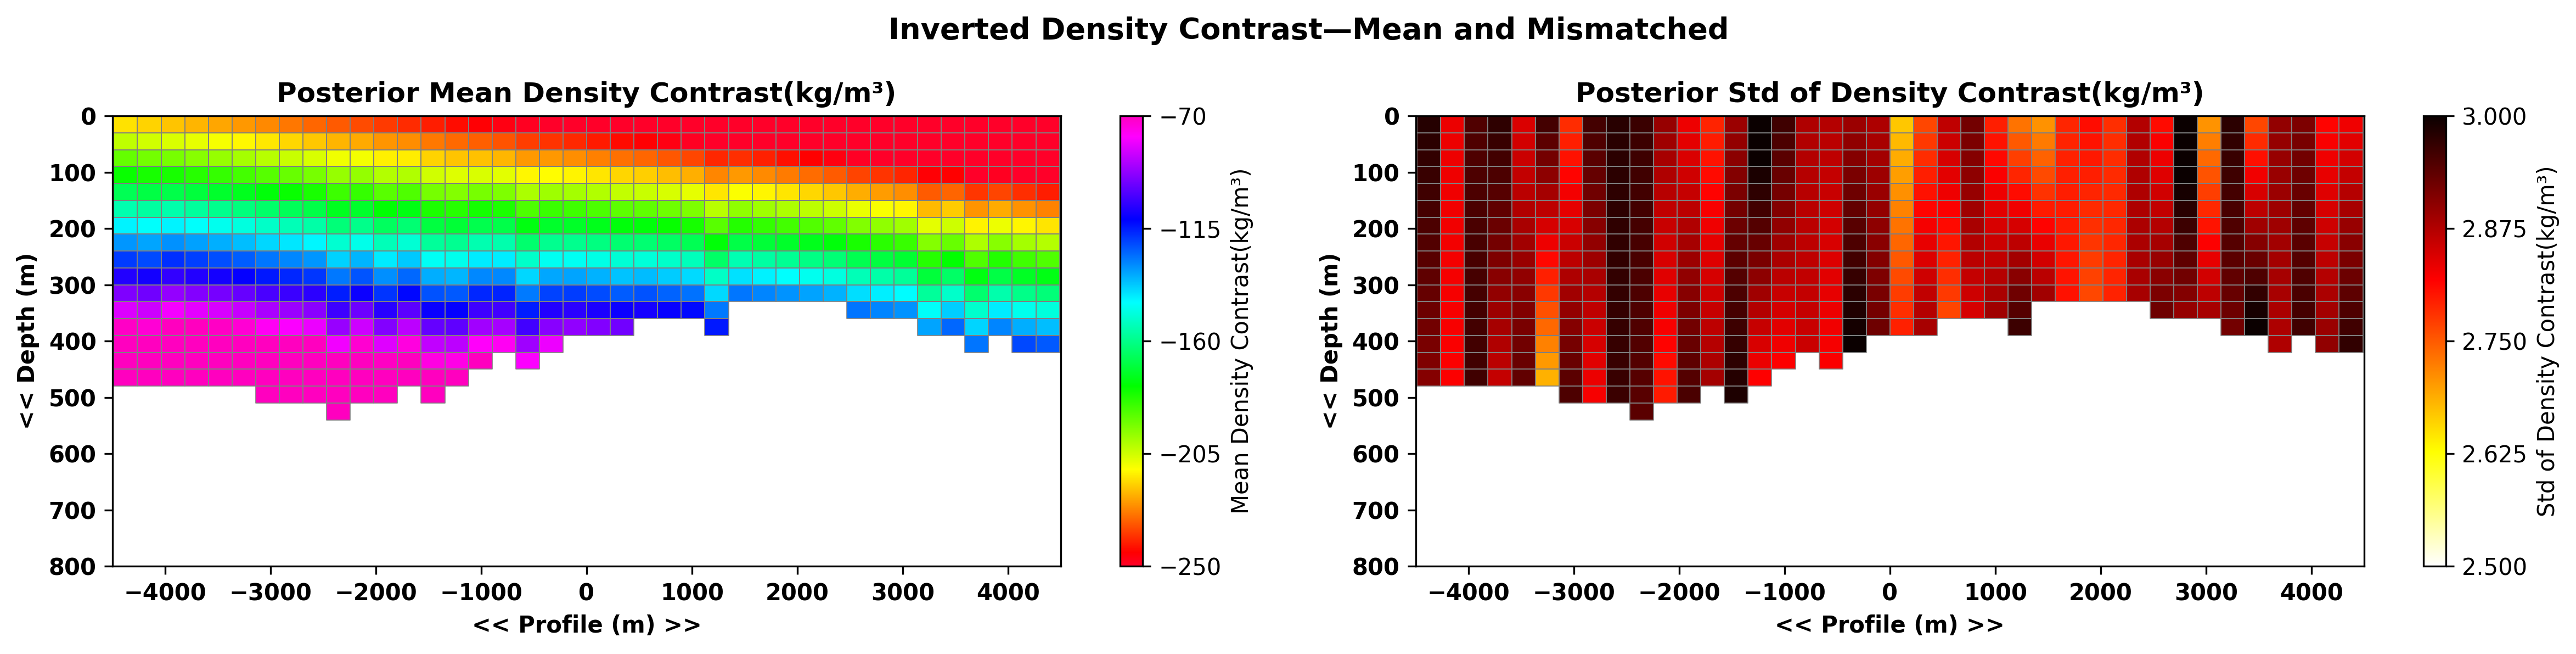

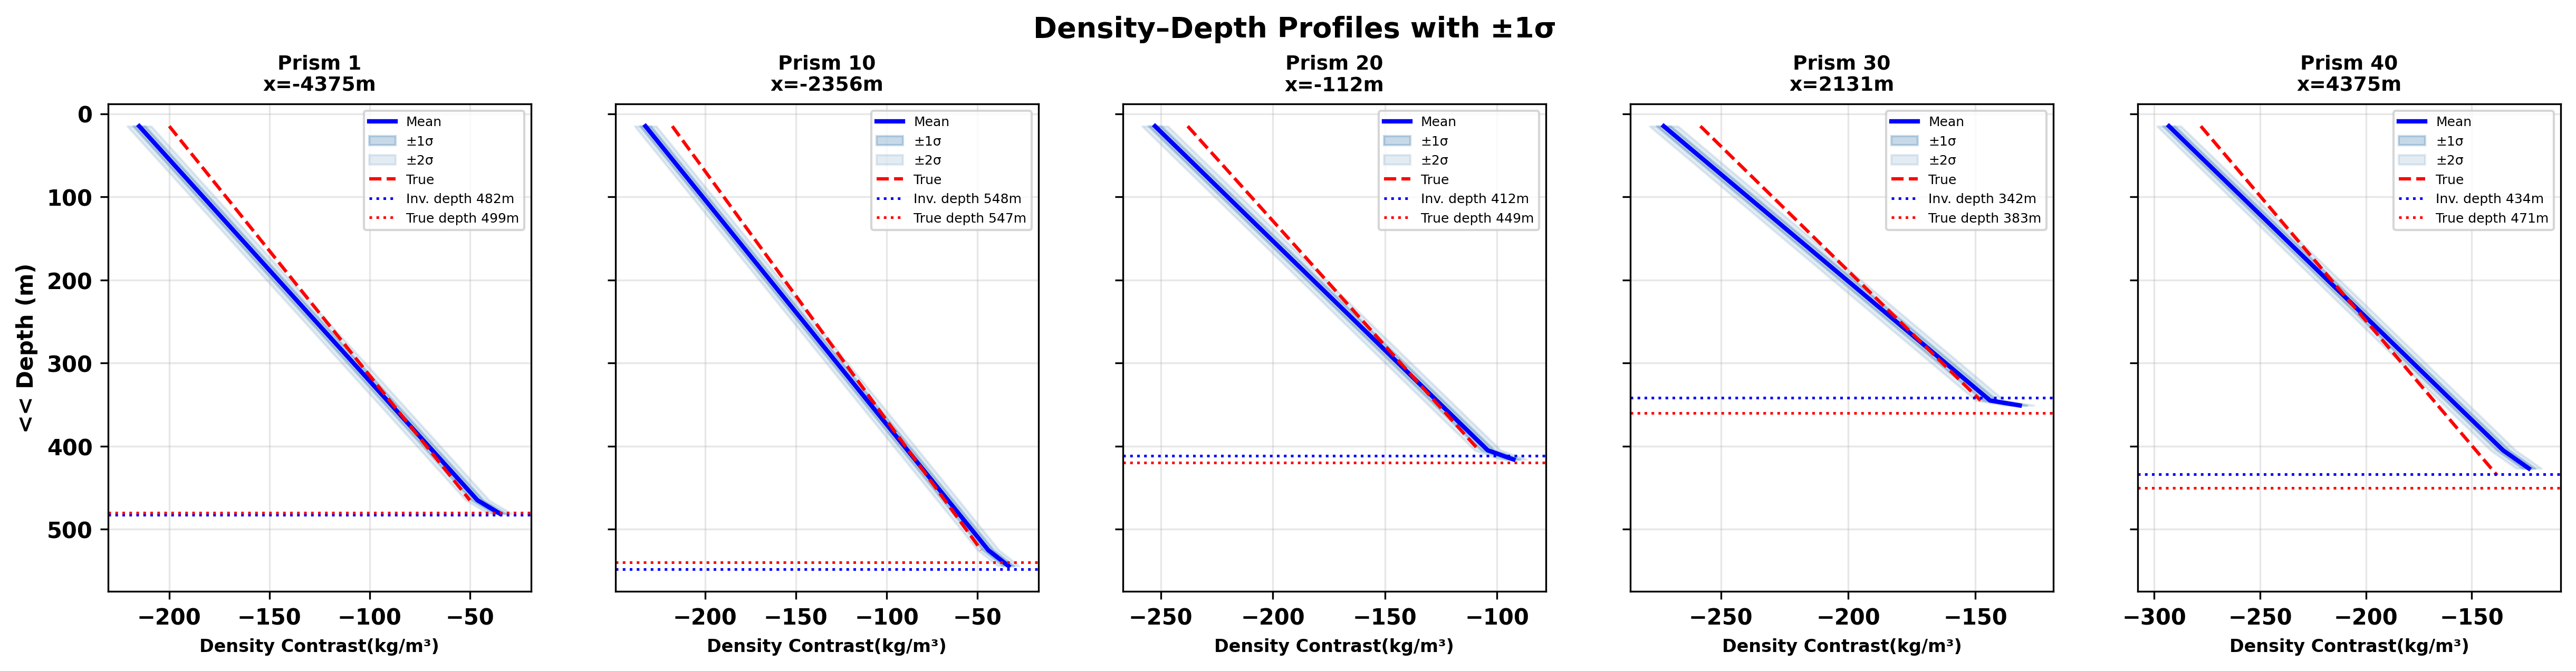

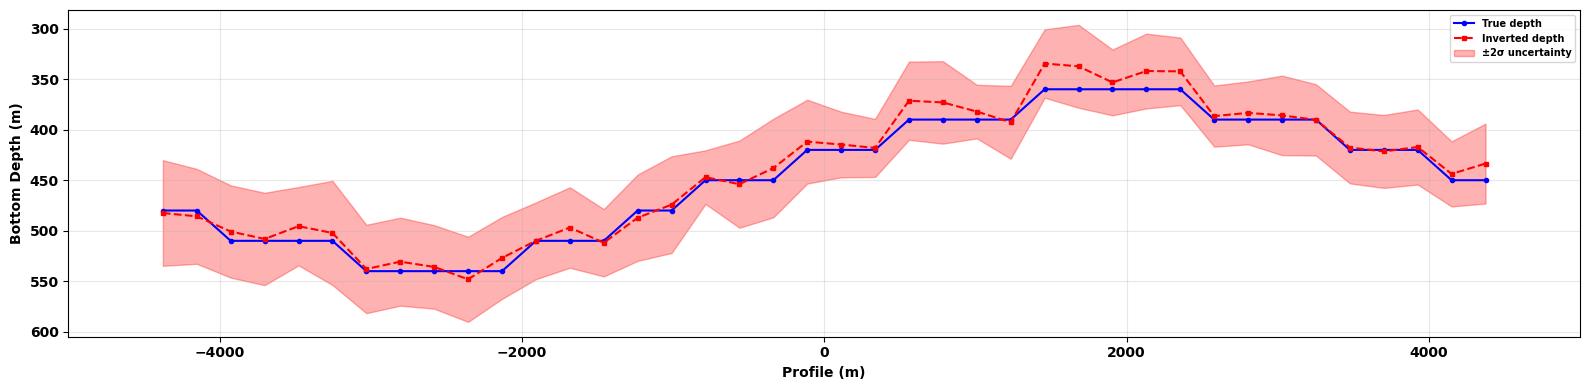

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

# Remove N_POLY_COEFFS as it's not used in this parameterization due to the last MCMC run's parameterization
# N_POLY_COEFFS   = 4

# ── Reconstruct density mean and std per prism per layer ─────
params7 = mcmc1.get_samples()
n_draws = params7["k_scale"].shape[0]

inverted_depths     = np.array([params7[f"B_D1_{i+1}"].mean() for i in range(n)])
inverted_depths_std = np.array([params7[f"B_D1_{i+1}"].std()  for i in range(n)])



#min_den   = float(np.nanmin(all_means)) - 5 if all_means.size > 0 else -310.0 # Default if emptyt
min_den=-250
max_den = -70
#max_den   = float(np.nanmax(all_means)) + 5 if all_means.size > 0 else -130.0 # Default if empty
min_std   = 2.5
max_std = 3
#max_std   = float(np.nanmax(all_stds)) if all_stds.size > 0 else 1.0 # Default if empty


# ============================================================
# FIGURE 1 — Mean density + uncertainty side by side
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
fig.dpi = 300
fig.suptitle("Inverted Density Contrast—Mean and Mismatched", fontsize=13, weight='bold')


cmap_den = plt.get_cmap('gist_rainbow', 1000)
cmap_unc = plt.get_cmap('hot_r', 1000)       # white=low uncertainty, red=high

for i in range(n):
    z_v_1  = np.arange(0, inverted_depths[i] + 1, 30)
    n_ref  = len(np.arange(0,inverted_depths[i] + 1, 30)) - 1
    xs_i   = xs_V[i]
    xs_ip1 = xs_V[min(i + 1, n)]
    density1_min_std = params7[f"density_min_{i+1}"].std()
    density1_max_std = params7[f"density_max_{i+1}"].std()
    den_min_1=density1_min[i]
    den_max_1=density1_max[i]
    den1_inv_V= np.linspace(den_min_1,den_max_1,n_ref)
    den1_inv_std = np.linspace(density1_min_std, density1_max_std, n_ref)
    for j in range(len(z_v_1) - 1):
        k_c   = min(j, n_ref - 1)
        #rho_j = params7[f"density{i+1}_{k_c+1}"].mean()
        #rho_std = params7[f"density{i+1}_{k_c+1}"].std()
        rho_j=den1_inv_V[j]
        rho_std=den1_inv_std[j]
        index_value_V = np.clip((rho_j - minimum_V) / diff_V, 0, 1)
        color_V = cmap_V(index_value_V)

        idx_std  = np.clip((rho_std - min_std) / (max_std - min_std), 0, 1)
        color_std = cmap_unc(idx_std)
        coord_V = [
            [xs_i,   z_v_1[j]],
            [xs_ip1, z_v_1[j]],
            [xs_ip1, z_v_1[j + 1]],
            [xs_i,   z_v_1[j + 1]],
            [xs_i,   z_v_1[j]]
        ]
        xc, yc = zip(*coord_V)
        axs[0].plot(xc, yc, 'grey', linewidth=0.4)
        axs[0].fill(xc, yc, facecolor=color_V)
        axs[1].plot(xc, yc, 'grey', linewidth = 0.4)
        axs[1].fill(xc, yc, facecolor=color_std)


for ax in axs:
    ax.set_xlim(-4500, 4500)
    ax.set_ylim(800, 0)
    ax.set_xlabel("<< Profile (m) >>", weight='bold')
    ax.set_ylabel("<< Depth (m)",      weight='bold')

axs[0].set_title("Posterior Mean Density Contrast(kg/m³)", weight='bold')
axs[1].set_title("Posterior Std of Density Contrast(kg/m³)", weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= True,weight='bold')

# Colorbars
norm_den = mpl.colors.Normalize(vmin=min_den, vmax=max_den)
sm_den   = plt.cm.ScalarMappable(cmap=cmap_den, norm=norm_den)
sm_den.set_array([])
plt.colorbar(sm_den, ax=axs[0], label='Mean Density Contrast(kg/m³)',
             ticks=np.linspace(min_den, max_den, 5))

norm_std = mpl.colors.Normalize(vmin=min_std, vmax=max_std)
sm_std   = plt.cm.ScalarMappable(cmap=cmap_unc, norm=norm_std)
sm_std.set_array([])
plt.colorbar(sm_std, ax=axs[1], label='Std of Density Contrast(kg/m³)',
             ticks=np.linspace(min_std, max_std, 5))

plt.tight_layout()
#plt.savefig("density_mean_and_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 2 — Per-prism density-depth profiles with ±1σ band
# For selected prisms spread across the profile
# ============================================================
selected_prisms = [0, 9, 19, 29, 39]   # adjust to taste
n_sel = len(selected_prisms)

fig2, axs2 = plt.subplots(1, n_sel, figsize=(4 * n_sel, 4), sharey=True)
fig2.dpi  = 300
fig2.suptitle("Density–Depth Profiles with ±1σ", fontsize=13, weight='bold',y=1.02)

for ax, i in zip(axs2, selected_prisms):
    z_grid   = Z_GRID_PER_PRISM[i]
    n_layers = N_LAYERS_PER_PRISM[i]

    # Depth axis — midpoint of each layer
    z_mids = np.array([
        (float(z_grid[k]) + (float(z_grid[k+1]) if k < n_layers-1 else inverted_depths[i])) / 2
        for k in range(n_layers)
    ])




    # Posterior mean
    #ax.plot(rho_mean, z_mids, 'b-', linewidth=2, label='Mean')

    ## Inverted density profile for this prism
    den_min_1=density1_min[i]
    den_max_1=density1_max[i]
    density1_min_std = params7[f"density_min_{i+1}"].std()
    density1_max_std = params7[f"density_max_{i+1}"].std()
    den1_inv_V= np.linspace(den_min_1,den_max_1,n_layers)
    den1_inv_std = np.linspace(density1_min_std, density1_max_std, n_layers)

    ax.plot(den1_inv_V, z_mids, 'b-', linewidth=2, label='Mean')

     # ±1σ band
    ax.fill_betweenx(z_mids,
                     den1_inv_V - den1_inv_std,
                     den1_inv_V + den1_inv_std,
                     alpha=0.3, color='steelblue', label='±1σ')
   # ±2σ band
    ax.fill_betweenx(z_mids,
                     den1_inv_V - 2*den1_inv_std,
                     den1_inv_V + 2*den1_inv_std,
                     alpha=0.15, color='steelblue', label='±2σ')

    # True density profile for this prism
    true_layers = density_layered[i, ~np.isnan(density_layered[i])]
    z_true = np.arange(0, BD[i] + 1, 30)
    z_true_mids = (z_true[:-1] + z_true[1:]) / 2
    ax.plot(true_layers, z_true_mids, 'r--', linewidth=1.5, label='True')

    # Inverted depth marker
    ax.axhline(inverted_depths[i], color='blue',  linestyle=':', linewidth=1.2,
               label=f'Inv. depth {inverted_depths[i]:.0f}m')
    ax.axhline(BD[i],           color='red',   linestyle=':', linewidth=1.2,
               label=f'True depth {bd1_0[i]:.0f}m')

    ax.set_title(f"Prism {i+1}\nx={co0[i]:.0f}m", fontsize=9, weight='bold')
    ax.set_xlabel("Density Contrast(kg/m³)", fontsize=8, weight = 'bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

axs2[0].set_ylabel("<< Depth (m)", weight='bold')
plt.setp(axs2[0].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs2[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs2[2].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs2[3].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs2[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs2[4].get_xticklabels(), visible= True,weight='bold')


# Panel 1 — Depth comparison
fig3, axs3 = plt.subplots(1, 1, figsize=(16, 4), sharey=True)

axs3.plot(co0, BD, 'b-o', markersize=3, linewidth=1.5, label='True depth')
axs3.plot(co0, inverted_depths, 'r--s', markersize=3, linewidth=1.5,
            label='Inverted depth')
axs3.fill_between(co0,
                    inverted_depths - 2*inverted_depths_std,
                    inverted_depths + 2*inverted_depths_std,
                    alpha=0.3, color='red', label='±2σ uncertainty')
axs3.set_ylabel("Bottom Depth (m)", fontsize=10, weight='bold')
axs3.set_xlabel("Profile (m)", fontsize=10, weight='bold')
axs3.invert_yaxis()
axs3.legend(prop={'weight': 'bold', 'size': 7})
axs3.set_xlim(-5000, 5000)
axs3.grid(True, alpha=0.3)
plt.setp(axs3.get_xticklabels(), visible= True,weight='bold')
plt.setp(axs3.get_yticklabels(), visible= True,weight='bold')

plt.tight_layout()
#plt.savefig("density_with_transparency.png", dpi=300, bbox_inches='tight')
plt.show()
